# Прикладные задачи анализа данных

## Домашнее задание 4

В этой работе мы будем решать задачу рекомендаций музыки. Для этого мы реализуем метод коллаборативной фильтрации и модель со скрытыми переменными, сравним их между собой и попытаемся сделать выводы. Во всех заданиях разрешается переписывать код по своему усмотрению, предложенные шаблоны несут лишь рекомендательный характер.

In [ ]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [ ]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [ ]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (1 балл).** Реализуйте метрику $MAP@k$.

In [ ]:
def apk(relevant, predicted, k=20):
  if not relevant:
    return 0.0

  if len(predicted)>k:
    predicted = predicted[:k]

  score = 0.0
  num_hits = 0.0

  for i, p in enumerate(predicted):
    if p in relevant and p not in predicted[:i]:
      num_hits+=1.0
      score+= num_hits / (i+1.0)

  return score / min(len(relevant), k)

def mapk(relevant, predicted, k=20):
  return np.mean([apk(a, p, k) for a, p in zip(relevant, predicted)])



In [ ]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [ ]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings.append(user_data[:-num_test_samples])

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [ ]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [ ]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [ ]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [ ]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [ ]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [ ]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [ ]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (1 балл).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [ ]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: np.array, k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        for user_id in range(self.n_users):
          user_recommendations = self.recommend(user_id)
          test_preds.append(user_recommendations)

        test_preds = self.remove_train_items(test_preds, k)

        return test_preds

## Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать две метрики:

1. Корреляция Пирсона $$s(u, v) = \frac{\sum_{i \in I_u \cap I_v} r_{ui}r_{vi}}{\sqrt{\sum_{i \in I_u} r_{ui} ^2}\sqrt{\sum_{i \in I_v} r_{vi}^2}} $$

2. Мера Жаккара

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Корреляция Пирсона немного видоизменена, чтобы подходить под нашу задачу.


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.1 (1 балл).** Реализуйте функцию подсчета корреляции Пирсона.

**Задание 3.2 (1 балл).** Реализуйте функцию подсчета меры Жаккара.

Функции принимают матрицу оценок и вектор оценок пользователя $u$ и возвращают вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [ ]:
def pearson(ratings: np.array, user_vector: np.array) -> np.array:

    user_mean = user_vector.mean()
    user_center = user_vector - user_mean

    ratings_mean = ratings.mean(axis=1).reshape(-1, 1)
    ratings_center = ratings - ratings_mean

    numerator = np.sum(ratings_center * user_center, axis=1)

    denominator = np.sqrt(np.sum(ratings_center**2, axis=1)) * np.sqrt(np.sum(user_center**2))
    denominator = np.where(denominator==0, 1, denominator)

    pearson_corr = numerator / denominator
    return pearson_corr


def jaccard(ratings: np.array, user_vector: np.array) -> np.array:

    binarized_ratings = (ratings > 0).astype(int)
    binarized_user_vector = (user_vector > 0).astype(int)

    intersection = np.sum(binarized_ratings + binarized_user_vector, axis=1)
    union = np.sum(binarized_ratings + binarized_user_vector, axis=1) - intersection
    union = np.where(union == 0, 1, union)

    jaccard_similarity = intersection / union
    return jaccard_similarity

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок.


In [ ]:
class User2User(BaseModel):
    def __init__(self, ratings, similarity_func):
        super().__init__(ratings)

        assert similarity_func in [pearson, jaccard]

        self.similarity_func = similarity_func
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """

        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):

        user_vector = self.R[uid]
        similarities = self.similarity(user_vector)

        weighted_sum = np.zeros(self.n_items)
        similarity_sum = np.zeros(self.n_items)

        for other_uid in range(self.n_users):
          if other_uid == uid:
            continue
          other_user_vector = self.R[other_uid]
          weighted_sum += similarities[other_uid] * other_user_vector
          similarity_sum += similarities[other_uid] * (other_user_vector > 0).astype(float)

        similarity_sum = np.where(similarity_sum == 0, 1, similarity_sum)
        predicted_ratings = weighted_sum / similarity_sum

        recommended_tracks = np.argsort(-predicted_ratings)

        return recommended_tracks

**Задание 5 (1 балл).** Постройте графики зависимости значений $MAP@k$ от разных $k$ для обоих функций похожести, сравните их между собой, а также с предсказаниями случайного алгоритма и сделайте выводы.

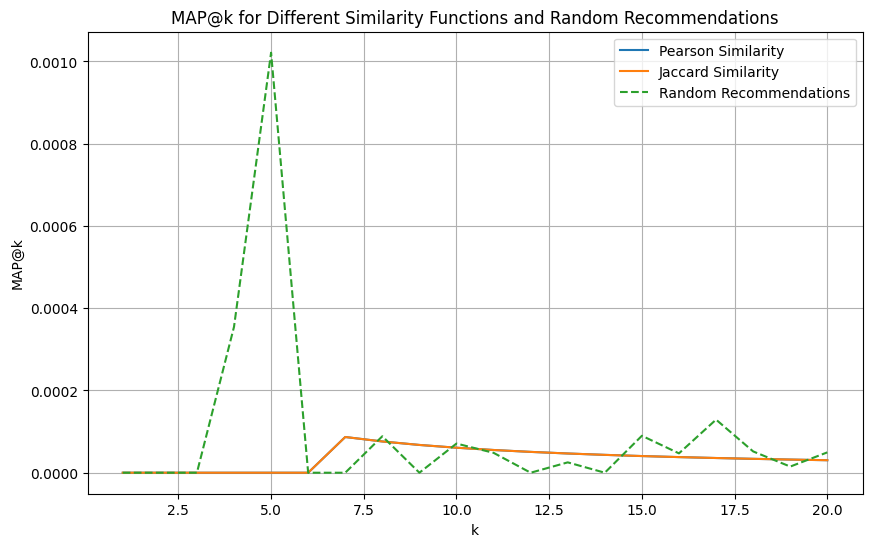

In [ ]:
def random_recommend(n_users, n_items, k):
    recommendations = np.zeros((n_users, k), dtype=int)
    for uid in range(n_users):
      recommendations[uid] = np.random.choice(n_items, k, replace=False)
    return recommendations

def evaluate_recommendations(model, test_relevant, k_values):
    map_scores = []
    for k in k_values:
      test_predictions = model.get_test_recommendations(k)
      map_score = mapk(test_relevant, test_predictions, k)
      map_scores.append(map_score)
    return map_scores


k_values = range(1, 21)

user2user_pearson = User2User(train_ratings, pearson)
user2user_jaccard = User2User(train_ratings, jaccard)

map_pearson = evaluate_recommendations(user2user_pearson, test_relevant, k_values)
map_jaccard = evaluate_recommendations(user2user_jaccard, test_relevant, k_values)

# Оценка случайных рекомендаций
n_users, n_items = user2user_pearson.R.shape
map_random = []
for k in k_values:
    random_recommendations = random_recommend(n_users, n_items, k)
    map_score = mapk(test_relevant, random_recommendations, k)
    map_random.append(map_score)


plt.figure(figsize=(10, 6))
plt.plot(k_values, map_pearson, label='Pearson Similarity')
plt.plot(k_values, map_jaccard, label='Jaccard Similarity')
plt.plot(k_values, map_random, label='Random Recommendations', linestyle='--')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('MAP@k for Different Similarity Functions and Random Recommendations')
plt.legend()
plt.grid(True)
plt.show()

**Задание 6 (1.5 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

In [ ]:
import time
from scipy.sparse import csr_matrix

def pearson(ratings: np.array, user_vector: np.array) -> np.array:

    user_mean = user_vector.mean()
    user_center = user_vector - user_mean

    ratings_mean = ratings.mean(axis=1)
    ratings_center = ratings - ratings_mean

    numerator = ratings_center.multiply(user_center).sum(axis=1)

    denominator = np.sqrt(ratings_center.multiply(ratings_center).sum(axis=1)) * np.sqrt(user_center.multiply(user_center).sum())
    denominator = np.where(denominator==0, 1, denominator)

    pearson_corr = numerator / denominator
    return np.array(pearson_corr).flatten()


def jaccard(ratings: csr_matrix, user_vector: csr_matrix) -> np.array:

    binarized_ratings = ratings > 0
    binarized_user_vector = user_vector > 0

    intersection = binarized_ratings.multiply(binarized_user_vector).sum(axis=1)
    union = binarized_ratings.sum(axis=1) + binarized_user_vector.sum() - intersection
    union = np.where(union == 0, 1, union)

    jaccard_similarity = intersection / union
    return np.array(jaccard_similarity).flatten()

def random_recommend(n_users, n_items, k):
    recommendations = np.zeros((n_users, k), dtype=int)
    for uid in range(n_users):
        recommendations[uid] = np.random.choice(n_items, k, replace=False)
    return recommendations

def evaluate_recommendations(model, test_relevant, k_values):
    map_scores = []
    for k in k_values:
        test_predictions = model.get_test_recommendations(k)
        map_score = mapk(test_relevant, test_predictions, k)
        map_scores.append(map_score)
    return map_scores

start_time = time.time()
k_values = range(1, 21)
user2user_pearson = User2User(train_ratings, pearson)
user2user_jaccard = User2User(train_ratings, jaccard)

map_pearson = evaluate_recommendations(user2user_pearson, test_relevant, k_values)
map_jaccard = evaluate_recommendations(user2user_jaccard, test_relevant, k_values)

n_users, n_items = user2user_pearson.R.shape
map_random = []
for k in k_values:
    random_recommendations = random_recommend(n_users, n_items, k)
    map_score = mapk(test_relevant, random_recommendations, k)
    map_random.append(map_score)

plt.figure(figsize=(10, 6))
plt.plot(k_values, map_pearson, label='Pearson Similarity')
plt.plot(k_values, map_jaccard, label='Jaccard Similarity')
plt.plot(k_values, map_random, label='Random Recommendations', linestyle='--')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('MAP@k for Different Similarity Functions and Random Recommendations')
plt.legend()
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")


ValueError: operands could not be broadcast together with shapes (241,67313) (241,) 

Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [ ]:
user_id = np.random.randint(0, model.n_users)

NameError: name 'model' is not defined

In [ ]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
494,Paganini Rhapsody (On Caprice 24),"['David Garrett', 'Niccolò Paganini']"
646,"Andante and Theme from Swan Lake, Act II, Op. 20","['Eugen Cicero', 'Pyotr Ilyich Tchaikovsky']"
647,"Valse in C sharp minor, Op. 64, No. 2","['Eugen Cicero', 'Фридерик Шопен']"
648,Hungarian Rhapsody No. 2,"['Eugen Cicero', 'Ferenc Liszt']"
649,Etude in G sharp minor (La Campanella),"['Eugen Cicero', 'Niccolò Paganini', 'Ferenc L..."
650,Solfeggio in C minor,"['Eugen Cicero', 'Карл Филипп Эммануил Бах']"
1379,All Fall Down,['OneRepublic']
1548,Dreamworld,['Robin Thicke']
1649,Cosmic Love,['Florence + The Machine']
2199,Secrets,['OneRepublic']


In [ ]:
preds = model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

NameError: name 'model' is not defined

In [ ]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
65569,Little Do You Know Beat Cry,['Yagih Mael']
65897,Life Goes On,['Oliver Tree']
65904,Gdzie jest biały węgorz ? (Zejście),['Cypis']
65918,Him & Her,['Pacino']
65948,I WANT YOU BACK,['Dazel Ukuto']
65967,Levan Polka,"['Dance', 'Tendência', 'Baila']"
66260,Levan Polkka,['Dj Mix Urbano']
66261,Kulikitaka Challenge,['Dj Mix Urbano']
66299,In Da Getto,"['J. Balvin', 'Skrillex']"
66314,Entrenamiento en el Gym,['Gimnasio de motivación']


### Часть 2. Модель со скрытыми переменными

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно.

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

**Задание 7 (1.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастческим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

**LFM:**

Ответ: для каждого рейтинга вычисляем ошибку прогноза - eᵤᵢ = rᵤᵢ - ̂rᵤᵢ

выводим градиенты:

xᵤ <- xᵤ + η * (eᵤᵢ * yᵢ - λ * xᵤ)

yᵢ <- yᵢ + η * (eᵤᵢ * xᵤ - λ * yᵢ)

\\
**ALS:**

Ответ:

для каждого пользователя u:

pᵤ = (∑i∈Iu qi qiT +λI)−1(∑i∈Iu rui qi )

для каждого объекта i:

qi ←(∑u∈Ui pu puT +λI)−1(∑u∈Ui rui pu )

---





**Задание 8 (2 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [ ]:
class HiddenVars(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.01

    def fit(self, num_iters=5):
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':

                for u, i, r_ui in zip(self.ratings['userId'], self.ratings['trackId'], self.ratings['rating']):
                  pred_ui = np.dot(self.P[u], self.Q[i])
                  error_ui = r_ui - pred_ui
                  self.P[u] += self.lr * (error_ui * self.Q[i] - self.lamb * self.P[u])
                  self.Q[i] += self.lr * (error_ui * self.P[u] - self.lamb * self.Q[i])

            elif self.mode == 'als':

                for u in range(self.n_users):
                  I_u = np.where(self.R[u] != 0)[0]
                  n_u = len(I_u)
                  if n_u == 0:
                    continue
                  Q_Iu = self.Q[I_u]
                  r_u = self.R[u, I_u]
                  self.P[u] = np.linalg.solve(np.dot(Q_Iu.T, Q_Iu) + self.lamb * n_u * np.eye(self.dim),
                                              np.dot(Q_Iu.T, r_u))
                for i in range(self.n_items):
                  U_i = np.where(self.R[:, i] != 0)[0]
                  m_i = len(U_i)
                  if m_i == 0:
                    continue
                  P_Ui = self.P[U_i]
                  r_i = self.R[U_i, i]

                  self.Q[i] = np.linalg.solve(np.dot(P_Ui.T, P_Ui) + self.lamb * m_i * np_eye(self.dim),
                                              np.dot(P_Ui.T, r_i))


    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [ ]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

In [ ]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
5517,Варвара,['Би-2'],0.649796
17328,Я хочу быть с тобой,['Nautilus Pompilius'],0.646846
2058,Последний герой,['КИНО'],0.640997
5872,Я свободен,['Кипелов'],0.606749
2060,Хочу перемен,['КИНО'],0.603231
5515,Романс,['Сплин'],0.590318
24284,Как на войне,['Агата Кристи'],0.586219
4463,Holiday,['Green Day'],0.576644
2179,Восьмиклассница,['КИНО'],0.570639
